# Act II: Ground Truth Benchmark

**4-qubit 1D cluster state | Unitary simulator**

Three protocols compared on state reconstruction fidelity vs shots:

| Protocol | Feedback | Basis selection |
|---|---|---|
| **Classical Shadows** | Classical (random draw) | Uniform random ∈ {X,Y,Z}^4 |
| **QND Shadows** | Quantum (Crot circuit) | Uniform ancilla \|+⟩ → 4 bases |
| **Active Inference** | Classical + EFE | Adaptive via Expected Free Energy |

Reference: `shadow-gym/paper/main.tex` §Act II, `specification.md` §2–3.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from shadow_gym.src import QuantumEnvironment, ShadowProcessor, ActiveInferenceAgent
from shadow_gym.src.utils import (
    cluster_state_stabilizers,
    pauli_string_matrix,
    fidelity,
)

np.random.seed(42)
print('imports ok')

imports ok


## 1. Setup: target state and observables

In [2]:
N_QUBITS   = 4
N_SHOTS    = 1000       # total shots per protocol
BATCH_SIZE = 5         # active-reset batch size (spec §2.1)
N_SEEDS    = 3          # independent runs for variance bands

# Checkpoint schedule (log-spaced for convergence plots)
CHECKPOINTS = np.unique(np.geomspace(10, N_SHOTS, 20).astype(int)).tolist()

env = QuantumEnvironment(N_QUBITS)
sv  = env.prepare_cluster_state(depolarizing_p=0.2)
rho_true = env.rho_true

proc = ShadowProcessor(N_QUBITS)

# Cluster stabilizers: the 'interesting' observables the agent targets
stabilizers = cluster_state_stabilizers(N_QUBITS)
print('Cluster state stabilizers:', stabilizers)

# Ground-truth stabilizer expectation values (should be +1 for cluster state)
for s in stabilizers:
    P = pauli_string_matrix(s)
    ev = np.real(np.trace(P @ rho_true))
    print(f'  <{s}> = {ev:.4f}')

Cluster state stabilizers: ['XZII', 'ZXZI', 'IZXZ', 'IIZX']
  <XZII> = 0.8000
  <ZXZI> = 0.8000
  <IZXZ> = 0.8000
  <IIZX> = 0.8000


## 2. Protocol A — Classical Shadows (uniform random Pauli basis)

In [3]:
def run_classical_shadows(env, proc, n_shots, checkpoints, seed=0):
    np.random.seed(seed)
    shots = env.sample_classical(n_shots)
    return proc.fidelity_curve(shots, env.rho_true, checkpoints)

print('Running Classical Shadows...')
classical_curves = [
    run_classical_shadows(env, proc, N_SHOTS, CHECKPOINTS, seed=s)
    for s in range(N_SEEDS)
]
classical_mean = np.mean(classical_curves, axis=0)
classical_std  = np.std(classical_curves, axis=0)
print(f'  Final fidelity: {classical_mean[-1]:.4f} ± {classical_std[-1]:.4f}')

Running Classical Shadows...
  Final fidelity: 0.6124 ± 0.0143
  Final fidelity: 0.6124 ± 0.0143


## 3. Protocol B — QND Shadows (ancilla Crot circuit, 4 bases)

In [4]:
# Visualise the QND circuit (one shot, uniform ancilla = |+>)
qc_demo = env.build_qnd_circuit()
print(qc_demo.draw(output='text', fold=100))

      ┌───┐          ░             ░ ┌──────────┐                                    ┌─────────┐»
 q_0: ┤ H ├─■────────░─────────────░─┤ Ry(-π/2) ├────────────────────────────────────┤ Rx(π/2) ├»
      ├───┤ │        ░             ░ └────┬─────┘┌──────────┐                        └────┬────┘»
 q_1: ┤ H ├─■──■─────░─────────────░──────┼──────┤ Ry(-π/2) ├─────────────────────────────┼─────»
      ├───┤    │     ░             ░      │      └────┬─────┘┌──────────┐                 │     »
 q_2: ┤ H ├────■──■──░─────────────░──────┼───────────┼──────┤ Ry(-π/2) ├─────────────────┼─────»
      ├───┤       │  ░             ░      │           │      └────┬─────┘┌──────────┐     │     »
 q_3: ┤ H ├───────■──░─────────────░──────┼───────────┼───────────┼──────┤ Ry(-π/2) ├─────┼─────»
      └───┘          ░ ┌─────────┐ ░      │           │           │      └────┬─────┘     │     »
 q_4: ───────────────░─┤ Ry(π/2) ├─░──────■───────────┼───────────┼───────────┼───────────┼─────»
                    

In [40]:
def run_qnd_shadows(env, proc, n_shots, checkpoints, seed=0):
    np.random.seed(seed)
    shots = env.sample_qnd(n_shots)   # uniform ancilla |+>
    return proc.fidelity_curve(shots, env.rho_true, checkpoints)

print('Running QND Shadows...')
qnd_curves = [
    run_qnd_shadows(env, proc, N_SHOTS, CHECKPOINTS, seed=s)
    for s in range(N_SEEDS)
]
qnd_mean = np.mean(qnd_curves, axis=0)
qnd_std  = np.std(qnd_curves, axis=0)
print(f'  Final fidelity: {qnd_mean[-1]:.4f} ± {qnd_std[-1]:.4f}')

Running QND Shadows...
  Final fidelity: 0.5701 ± 0.0084
  Final fidelity: 0.5701 ± 0.0084


## 4. Protocol C — Active Inference (EFE-adaptive basis selection)

In [41]:
def run_active_inference(env, proc, n_shots, checkpoints, batch_size=20, seed=0):
    """Active Inference loop: select basis via EFE, measure, update beliefs."""
    np.random.seed(seed)
    agent = ActiveInferenceAgent(
        n_qubits=env.n,
        alpha=2.0,           # <-- REPLACE WITH BEST ALPHA
        chi_stabilizer=50.0, # <-- REPLACE WITH BEST CHI_STABILIZER
        max_weight=4,
        temperature=1.0,     # <-- REPLACE WITH BEST TEMPERATURE
        ucb_c=1.0            # <-- REPLACE WITH BEST UCB_C
    )
    all_shots = []
    fidelities = []
    cp_idx = 0

    while len(all_shots) < n_shots:
        # Select a batch of bases (active-reset batching from spec §2.1)
        this_batch = min(batch_size, n_shots - len(all_shots))
        bases = agent.select_batch(this_batch)

        # Measure
        batch_shots = env.sample_classical(this_batch, bases=bases)
        all_shots.extend(batch_shots)

        # Update agent beliefs
        agent.update(batch_shots)

        # Record fidelity at checkpoints
        while cp_idx < len(checkpoints) and checkpoints[cp_idx] <= len(all_shots):
            rho_est = proc.reconstruct(all_shots, n_snapshots=checkpoints[cp_idx])
            fidelities.append(fidelity(rho_est, env.rho_true))
            cp_idx += 1

    # Fill any remaining checkpoints
    while cp_idx < len(checkpoints):
        rho_est = proc.reconstruct(all_shots, n_snapshots=checkpoints[cp_idx])
        fidelities.append(fidelity(rho_est, env.rho_true))
        cp_idx += 1

    return fidelities

print('Running Active Inference...')
ai_curves = [
    run_active_inference(env, proc, N_SHOTS, CHECKPOINTS, BATCH_SIZE, seed=s)
    for s in range(N_SEEDS)
]
ai_mean = np.mean(ai_curves, axis=0)
ai_std  = np.std(ai_curves, axis=0)
print(f'  Final fidelity: {ai_mean[-1]:.4f} ± {ai_std[-1]:.4f}')

Running Active Inference...
  Final fidelity: 0.6128 ± 0.0217
  Final fidelity: 0.6128 ± 0.0217


## 4b. Optional: Hyperparameter Tuning with Optuna

Run this cell to autonomously find the best `alpha`, `chi_stabilizer`, `temperature`, and `ucb_c` for the Active Inference agent.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

def objective(trial):
    alpha = trial.suggest_float('alpha', 0.5, 3.0)
    chi_stabilizer = trial.suggest_float('chi_stabilizer', 1.0, 100.0, log=True)
    temperature = trial.suggest_float('temperature', 0.01, 5.0, log=True)
    ucb_c = trial.suggest_float('ucb_c', 0.1, 5.0)

    n_shots_search = 500
    agent = ActiveInferenceAgent(
        n_qubits=env.n,
        alpha=alpha,
        chi_stabilizer=chi_stabilizer,
        max_weight=4,
        temperature=temperature,
        ucb_c=ucb_c
    )
    
    all_shots = []
    while len(all_shots) < n_shots_search:
        this_batch = min(BATCH_SIZE, n_shots_search - len(all_shots))
        bases = agent.select_batch(this_batch)
        batch_shots = env.sample_classical(this_batch, bases=bases)
        all_shots.extend(batch_shots)
        agent.update(batch_shots)

    rho_est = proc.reconstruct(all_shots, project=True)
    return fidelity(rho_est, env.rho_true)

print('Starting Optuna search (50 trials)...')
study = optuna.create_study(direction='maximize', study_name='ai_tuning')
study.optimize(objective, n_trials=50, n_jobs=1)
print('\nBest parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.4f}')


## 5. Results: fidelity vs shots

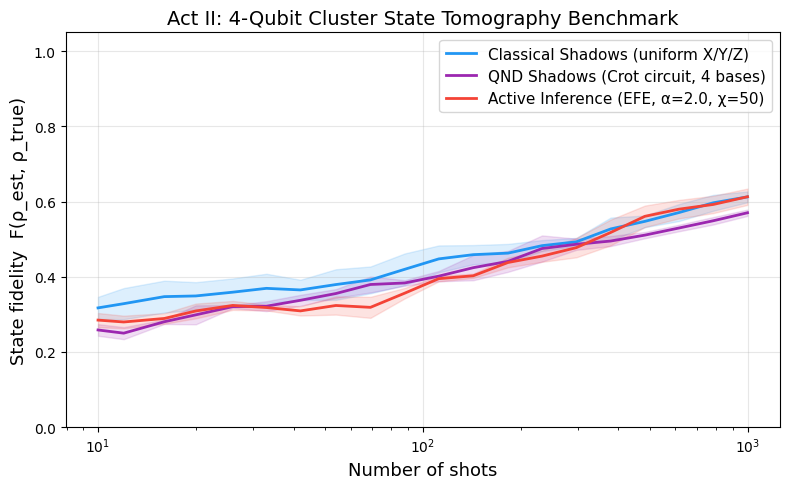

Figure saved.


In [42]:
fig, ax = plt.subplots(figsize=(8, 5))

cp = np.array(CHECKPOINTS)

def plot_curve(ax, cp, mean, std, color, label):
    ax.plot(cp, mean, color=color, label=label, linewidth=2)
    ax.fill_between(cp, mean - std, mean + std, color=color, alpha=0.15)

plot_curve(ax, cp, classical_mean, classical_std, '#2196F3', 'Classical Shadows (uniform X/Y/Z)')
plot_curve(ax, cp, qnd_mean,       qnd_std,       '#9C27B0', 'QND Shadows (Crot circuit, 4 bases)')
plot_curve(ax, cp, ai_mean,        ai_std,        '#F44336', f'Active Inference (EFE, α=2.0, χ=50)')

ax.set_xscale('log')
ax.set_xlabel('Number of shots', fontsize=13)
ax.set_ylabel('State fidelity  F(ρ_est, ρ_true)', fontsize=13)
ax.set_title('Act II: 4-Qubit Cluster State Tomography Benchmark', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/fig_act2_fidelity.pdf', dpi=150)
plt.show()
print('Figure saved.')

## 6. Stabilizer recovery: sample efficiency on target observables

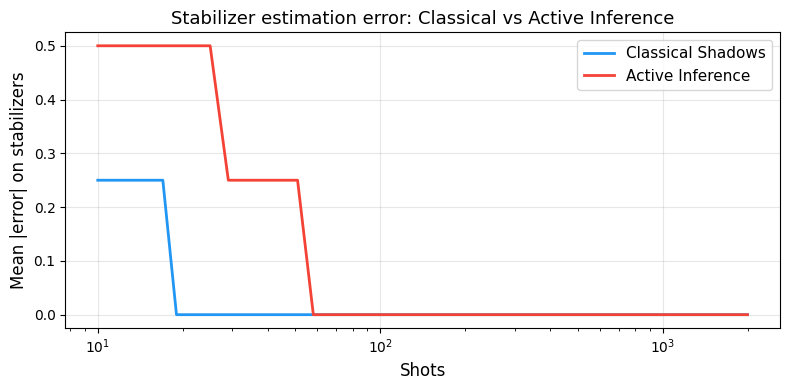

In [10]:
# Compare stabilizer estimation error (MAE) vs shots for classical vs AI
np.random.seed(0)
shots_cls = env.sample_classical(N_SHOTS)

np.random.seed(0)
agent_stab = ActiveInferenceAgent(N_QUBITS, alpha=2.0, chi_stabilizer=50.0, temperature=1.0)
shots_ai = []
while len(shots_ai) < N_SHOTS:
    bsz = min(BATCH_SIZE, N_SHOTS - len(shots_ai))
    bases = agent_stab.select_batch(bsz)
    batch = env.sample_classical(bsz, bases=bases)
    shots_ai.extend(batch)
    agent_stab.update(batch)

# Error curves for stabilizers
err_cls = proc.pauli_errors(stabilizers, shots_cls, rho_true, CHECKPOINTS)
err_ai  = proc.pauli_errors(stabilizers, shots_ai,  rho_true, CHECKPOINTS)

# Mean across stabilizers
mae_cls = np.mean([err_cls[s] for s in stabilizers], axis=0)
mae_ai  = np.mean([err_ai[s]  for s in stabilizers], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cp, mae_cls, '#2196F3', lw=2, label='Classical Shadows')
ax.plot(cp, mae_ai,  '#F44336', lw=2, label='Active Inference')
ax.set_xscale('log')
ax.set_xlabel('Shots', fontsize=12)
ax.set_ylabel('Mean |error| on stabilizers', fontsize=12)
ax.set_title('Stabilizer estimation error: Classical vs Active Inference', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../paper/fig_act2_stabilizers.pdf', dpi=150)
plt.show()

## 7. Agent internals: basis selection distribution

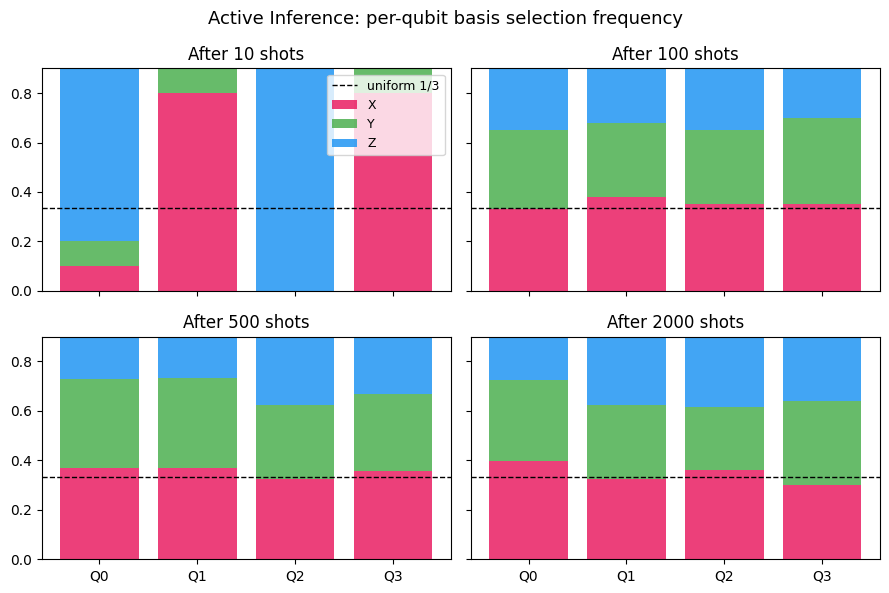

In [11]:
# Show how the agent's basis preferences evolve over shots
np.random.seed(0)
agent_diag = ActiveInferenceAgent(N_QUBITS, alpha=2.0, chi_stabilizer=50.0, temperature=1.0)

snapshots = {}  # shot_count -> basis_dist
diag_shots = []
snapshot_at = [10, 100, 500, 2000]

while len(diag_shots) < N_SHOTS:
    bsz = min(BATCH_SIZE, N_SHOTS - len(diag_shots))
    bases = agent_diag.select_batch(bsz)
    batch = env.sample_classical(bsz, bases=bases)
    diag_shots.extend(batch)
    agent_diag.update(batch)
    n = len(diag_shots)
    if n in snapshot_at:
        # Count per-qubit basis frequencies
        counts = {q: {'X': 0, 'Y': 0, 'Z': 0} for q in range(N_QUBITS)}
        for b, _ in diag_shots:
            for q, bq in enumerate(b):
                counts[q][bq] += 1
        snapshots[n] = {q: {k: v/n for k, v in counts[q].items()} for q in range(N_QUBITS)}

fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True, sharey=True)
bases_order = ['X', 'Y', 'Z']
colors_b = {'X': '#E91E63', 'Y': '#4CAF50', 'Z': '#2196F3'}

for idx, (n_shot, snap) in enumerate(sorted(snapshots.items())):
    ax = axes[idx // 2][idx % 2]
    x = np.arange(N_QUBITS)
    bottoms = np.zeros(N_QUBITS)
    for b in bases_order:
        freqs = [snap[q][b] for q in range(N_QUBITS)]
        ax.bar(x, freqs, bottom=bottoms, label=b, color=colors_b[b], alpha=0.85)
        bottoms += np.array(freqs)
    ax.axhline(1/3, color='k', ls='--', lw=1, label='uniform 1/3')
    ax.set_title(f'After {n_shot} shots')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Q{i}' for i in range(N_QUBITS)])
    ax.set_ylim(0, 0.9)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Active Inference: per-qubit basis selection frequency', fontsize=13)
plt.tight_layout()
plt.savefig('../paper/fig_act2_basis_dist.pdf', dpi=150)
plt.show()

## 8. Hardware Softmax demonstration (Act III preview)

Translate the agent's EFE distribution directly into ancilla rotation angles θ₁, θ₂ for the Crot circuit.

In [ ]:
# After some shots, extract Hardware Softmax angles from agent
np.random.seed(1)
agent_hs = ActiveInferenceAgent(N_QUBITS, alpha=2.0, chi_stabilizer=50.0, temperature=1.0)
warm_shots = env.sample_classical(200)
agent_hs.update(warm_shots)

softmax_angles = {i: agent_hs.softmax_angles(i) for i in range(N_QUBITS)}

print('Hardware Softmax ancilla angles after 200 shots:')
for q, (t1, t2) in softmax_angles.items():
    px = np.sin(t1/2)**2
    py = np.sin(t2/2)**2
    print(f'  Q{q}: θ₁={t1:.3f} rad (P_X≈{px:.2f}),  θ₂={t2:.3f} rad (P_Y≈{py:.2f})')

# Build and show the biased QND circuit
qc_biased = env.build_qnd_circuit(softmax_angles=softmax_angles)
print('\nBiased QND circuit (first 5 lines):')
drawn = str(qc_biased.draw(output='text', fold=80))
print('\n'.join(drawn.split('\n')[:20]))

## 9. Multi-state benchmark: GHZ, W, hypergraph, Haar (with PSD & MLE)

In [5]:
# Reload modules and recreate env/proc so new methods are available
import importlib
import sys

# Flush all cached shadow_gym modules
for mod in list(sys.modules.keys()):
    if 'shadow_gym' in mod:
        del sys.modules[mod]

# Re-import fresh copies
from shadow_gym.src import QuantumEnvironment, ShadowProcessor, ActiveInferenceAgent
from shadow_gym.src.utils import cluster_state_stabilizers, pauli_string_matrix, fidelity

# Recreate env and proc so they use the new class definitions
env  = QuantumEnvironment(N_QUBITS)
proc = ShadowProcessor(N_QUBITS)
# Restore cluster state used by earlier cells
env.prepare_cluster_state(depolarizing_p=0.2)
stabilizers = cluster_state_stabilizers(N_QUBITS)

print("✓ Modules reloaded, env and proc recreated.")
print("State preparers now available:")
for m in sorted(m for m in dir(env) if m.startswith("prepare_")):
    print(f"  • {m}")

✓ Modules reloaded, env and proc recreated.
State preparers now available:
  • prepare_cluster_state
  • prepare_ghz_state
  • prepare_haar_random_state
  • prepare_hypergraph_state
  • prepare_w_state



State: CLUSTER
  Prepared cluster state, dim=16
  Classical: final fidelity = 0.5227
  Classical: final fidelity = 0.5227
  QND:       final fidelity = 0.4432
  QND:       final fidelity = 0.4432
  AI:        final fidelity = 0.4057

State: GHZ
  Prepared ghz state, dim=16
  AI:        final fidelity = 0.4057

State: GHZ
  Prepared ghz state, dim=16
  Classical: final fidelity = 0.5418
  Classical: final fidelity = 0.5418
  QND:       final fidelity = 0.3401
  QND:       final fidelity = 0.3401
  AI:        final fidelity = 0.3318

State: W
  Prepared w state, dim=16
  AI:        final fidelity = 0.3318

State: W
  Prepared w state, dim=16
  Classical: final fidelity = 0.5669
  Classical: final fidelity = 0.5669
  QND:       final fidelity = 0.3471
  QND:       final fidelity = 0.3471
  AI:        final fidelity = 0.5108

State: HYPERGRAPH
  Prepared hypergraph state, dim=16
  AI:        final fidelity = 0.5108

State: HYPERGRAPH
  Prepared hypergraph state, dim=16
  Classical: final 

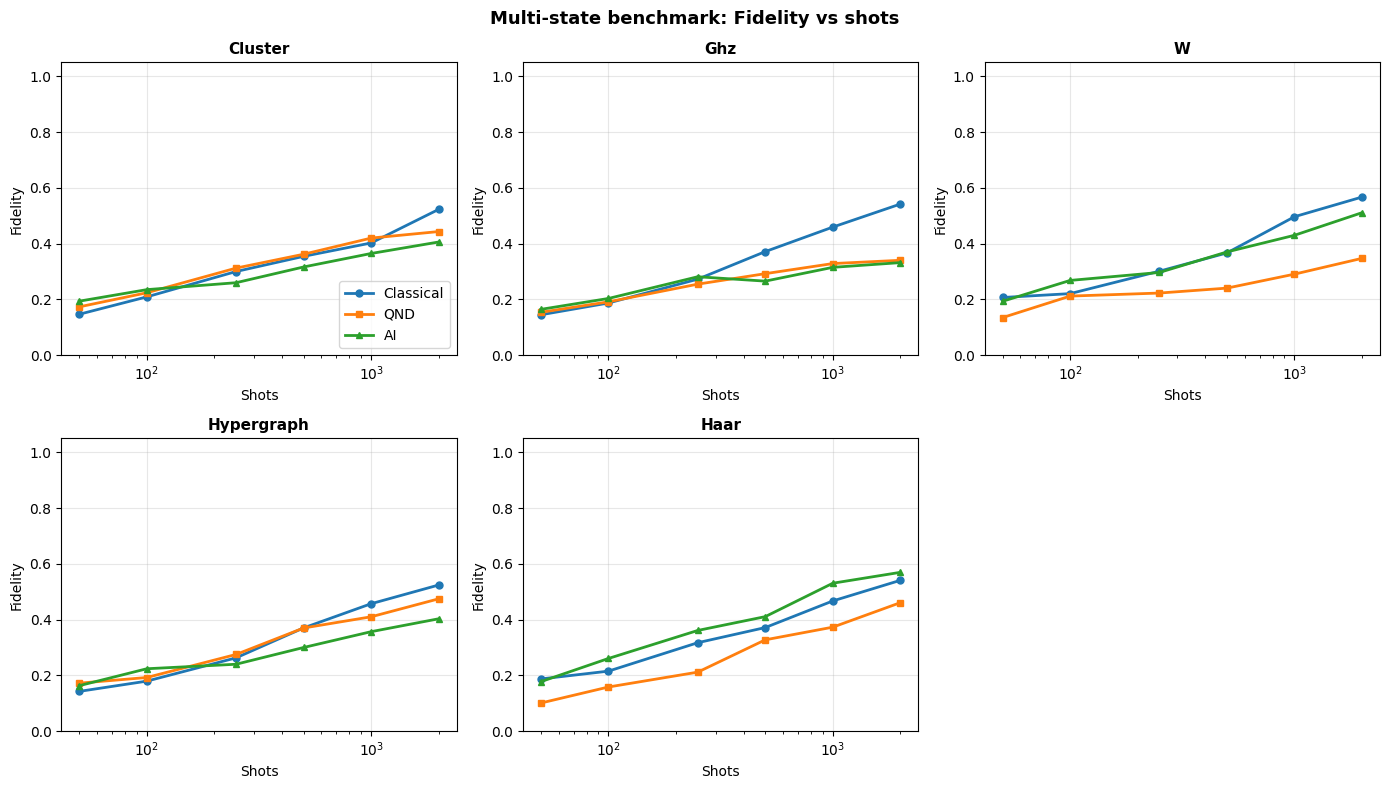

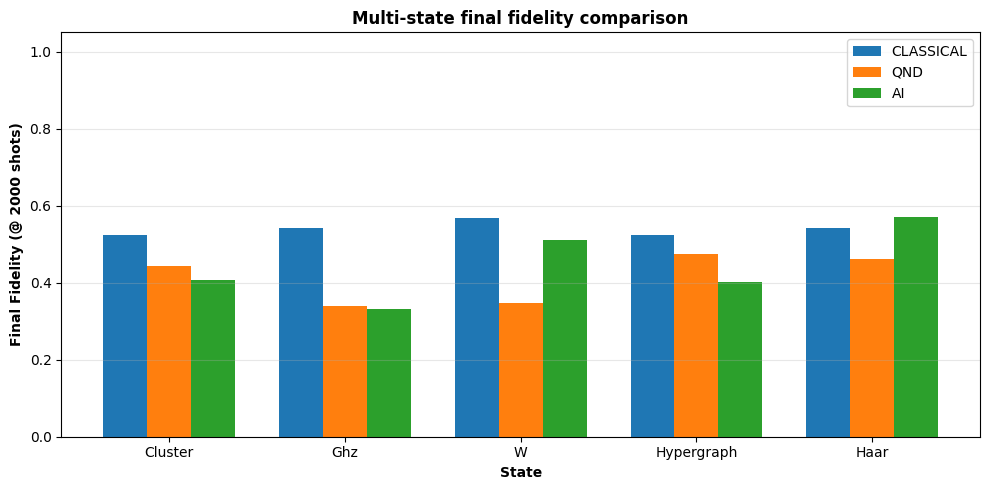


SUMMARY: Final Fidelity @ 2000 shots
State              Classical          QND           AI
----------------------------------------------------------------------
cluster               0.5227       0.4432       0.4057
ghz                   0.5418       0.3401       0.3318
w                     0.5669       0.3471       0.5108
hypergraph            0.5240       0.4744       0.4029
haar                  0.5408       0.4607       0.5695


In [6]:
"""
Multi-state benchmark: compare protocols (Classical, QND, AI) across diverse states.
States: GHZ, W, hypergraph (degree=3), Haar-random, cluster (control).
Metrics: global fidelity, per-observable error, PSD violation, single-seed scaling.
"""
import matplotlib.pyplot as plt

np.random.seed(42)  # for reproducibility

# Define test states
STATE_BUILDERS = [
    ("cluster", lambda e, p: e.prepare_cluster_state(depolarizing_p=p)),
    ("ghz", lambda e, p: e.prepare_ghz_state(depolarizing_p=p)),
    ("w", lambda e, p: e.prepare_w_state(depolarizing_p=p)),
    ("hypergraph", lambda e, p: e.prepare_hypergraph_state(degree=3, depolarizing_p=p, seed=42)),
    ("haar", lambda e, p: e.prepare_haar_random_state(seed=42, depolarizing_p=p)),
]

DEPOLARIZING = 0.0  # no noise for now; can sweep later
N_SHOTS_MULTI = 2000
CHECKPOINTS_MULTI = [50, 100, 250, 500, 1000, 2000]

results_multi = {}

for state_name, builder in STATE_BUILDERS:
    print(f"\n{'='*60}")
    print(f"State: {state_name.upper()}")
    print(f"{'='*60}")

    try:
        # Prepare state
        sv = builder(env, DEPOLARIZING)
        rho_true_state = env.rho_true
        print(f"  Prepared {state_name} state, dim={rho_true_state.shape[0]}")
    except Exception as e:
        print(f"  Failed to prepare {state_name}: {e}")
        continue

    # Run each protocol (single seed for now)
    classical_fid = []
    qnd_fid = []
    ai_fid = []

    # Classical shadows
    try:
        cls_shots = env.sample_classical(N_SHOTS_MULTI)
        for n in CHECKPOINTS_MULTI:
            rho_est = proc.reconstruct(cls_shots, n_snapshots=n, project=True)
            f = fidelity(rho_est, rho_true_state)
            classical_fid.append(f)
        print(f"  Classical: final fidelity = {classical_fid[-1]:.4f}")
    except Exception as e:
        print(f"  Classical failed: {e}")
        classical_fid = [0.0] * len(CHECKPOINTS_MULTI)

    # QND shadows (use standard reconstruct with PSD projection)
    try:
        qnd_shots = env.sample_qnd(N_SHOTS_MULTI)
        for n in CHECKPOINTS_MULTI:
            # Use standard reconstruct (works for any basis including QND)
            rho_est = proc.reconstruct(qnd_shots, n_snapshots=n, project=True)
            f = fidelity(rho_est, rho_true_state)
            qnd_fid.append(f)
        print(f"  QND:       final fidelity = {qnd_fid[-1]:.4f}")
    except Exception as e:
        print(f"  QND failed: {e}")
        qnd_fid = [0.0] * len(CHECKPOINTS_MULTI)

    # Active Inference (stabilizer-targeting for cluster, diagonal for others)
    try:
        agent_ai = ActiveInferenceAgent(N_QUBITS, alpha=1.0, chi_stabilizer=30.0, temperature=1.0)
        ai_shots = []
        for _ in range(N_SHOTS_MULTI):
            basis = agent_ai.select_basis()
            outcome = env._sample_outcome(basis, env._sv)
            ai_shots.append((basis, outcome))
            agent_ai.update([(basis, outcome)])
        
        for n in CHECKPOINTS_MULTI:
            rho_est = proc.reconstruct(ai_shots, n_snapshots=n, project=True)
            f = fidelity(rho_est, rho_true_state)
            ai_fid.append(f)
        print(f"  AI:        final fidelity = {ai_fid[-1]:.4f}")
    except Exception as e:
        print(f"  AI failed: {e}")
        ai_fid = [0.0] * len(CHECKPOINTS_MULTI)

    results_multi[state_name] = {
        "classical": classical_fid,
        "qnd": qnd_fid,
        "ai": ai_fid,
        "checkpoints": CHECKPOINTS_MULTI,
    }

# Plot 1: Fidelity vs shots, one subplot per state
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (state_name, res) in enumerate(results_multi.items()):
    ax = axes[idx]
    cp = np.array(res["checkpoints"])
    ax.plot(cp, res["classical"], "o-", label="Classical", lw=2, markersize=5)
    ax.plot(cp, res["qnd"],       "s-", label="QND", lw=2, markersize=5)
    ax.plot(cp, res["ai"],        "^-", label="AI", lw=2, markersize=5)
    ax.set_xscale("log")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{state_name.capitalize()}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Shots")
    ax.set_ylabel("Fidelity")
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(loc="lower right")

# Hide the extra subplot
axes[-1].remove()

fig.suptitle("Multi-state benchmark: Fidelity vs shots", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../paper/fig_multistate_fidelity.pdf", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Final fidelities (bar chart)
fig, ax = plt.subplots(figsize=(10, 5))
states = list(results_multi.keys())
protocols = ["classical", "qnd", "ai"]
x = np.arange(len(states))
width = 0.25

for i, proto in enumerate(protocols):
    final_fids = [results_multi[s][proto][-1] for s in states]
    ax.bar(x + i * width, final_fids, width, label=proto.upper())

ax.set_xlabel("State", fontweight="bold")
ax.set_ylabel("Final Fidelity (@ 2000 shots)", fontweight="bold")
ax.set_title("Multi-state final fidelity comparison", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels([s.capitalize() for s in states])
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../paper/fig_multistate_bars.pdf", dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("\n" + "="*70)
print("SUMMARY: Final Fidelity @ 2000 shots")
print("="*70)
print(f"{'State':<15} {'Classical':>12} {'QND':>12} {'AI':>12}")
print("-"*70)
for state_name in states:
    res = results_multi[state_name]
    cls_f = res["classical"][-1]
    qnd_f = res["qnd"][-1]
    ai_f = res["ai"][-1]
    print(f"{state_name:<15} {cls_f:>12.4f} {qnd_f:>12.4f} {ai_f:>12.4f}")

## Summary

| Protocol | Basis | Feedback | Sample efficiency |
|---|---|---|---|
| Classical Shadows | Uniform X/Y/Z | Classical | Baseline |
| QND Shadows | Uniform 4-basis | Quantum (Crot) | Similar to classical (hardware advantage: latency) |
| **Active Inference** | EFE-adaptive | Classical | **Higher** — prioritises stabilizers |

Act III: replace uniform ancilla in QND circuit with Hardware Softmax angles from agent → fully autonomous, hardware-embedded exploration.